# 06. Сводный отчет по подходам

Отчетный ноутбук пересчитывает метрики и строит графики для всех подходов: `answer_only`, `answer_description`, `nlp`, `efficientnet_only` и лучший текстовый подход + `efficientnet`.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymorphy3

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## Загрузка данных

In [2]:
DATA_PATH = Path("../data_with_efficientnet_features.csv")
df = pd.read_csv(DATA_PATH)

effnet_cols = [col for col in df.columns if col.startswith("effnet_feat_")]
assert effnet_cols, "В датасете не найдены колонки effnet_feat_*"

print(f"Rows: {len(df)}")
print(f"EfficientNet features: {len(effnet_cols)}")
df[["id", "answer", "description", "difficulty"]].head()

Rows: 327
EfficientNet features: 1280


,id,answer,description,difficulty
0,1,брауни,Коричневая английская Е (читается как и) = Bro...,0.4303
1,2,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,0.4010
2,3,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,0.3736
3,4,подоконник,Под О Конь и К,0.2045
4,5,редактор,Красный актер = Red Actor,0.3675


## Общие функции

In [3]:
RANDOM_STATE = 42


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
VOWELS = set("аеёиоуыэюя")
RARE_LETTERS = set("фщъёцэ")
morph = pymorphy3.MorphAnalyzer()


def clean_and_lemmatize(text):
    if pd.isna(text):
        return "пусто"
    words = re.findall(r"[а-яёa-z]+", str(text).lower())
    if not words:
        return "пусто"
    return " ".join(morph.parse(word)[0].normal_form for word in words)


def extract_text_stats(text, prefix=""):
    if pd.isna(text):
        text = ""
    text = str(text).lower().strip()
    if "|" in text:
        text = text.split("|")[0].strip()

    compact = text.replace(" ", "")
    words = [word for word in text.split() if word]
    letters = [char for char in compact if char.isalpha()]
    cyrillic_letters = [char for char in letters if "а" <= char <= "я" or char == "ё"]
    latin_letters = [char for char in letters if "a" <= char <= "z"]

    len_chars = len(compact)
    vowel_count = sum(char in VOWELS for char in compact)
    consonant_count = sum(char.isalpha() and char not in VOWELS for char in compact)
    rare_count = sum(char in RARE_LETTERS for char in compact)
    unique_chars = len(set(compact))

    return pd.Series(
        {
            f"{prefix}len_chars": len_chars,
            f"{prefix}len_words": len(words),
            f"{prefix}avg_word_len": len_chars / len(words) if words else 0.0,
            f"{prefix}vowel_count": vowel_count,
            f"{prefix}consonant_count": consonant_count,
            f"{prefix}rare_count": rare_count,
            f"{prefix}unique_chars": unique_chars,
            f"{prefix}vowel_ratio": vowel_count / len_chars if len_chars else 0.0,
            f"{prefix}rare_ratio": rare_count / len_chars if len_chars else 0.0,
            f"{prefix}unique_ratio": unique_chars / len_chars if len_chars else 0.0,
            f"{prefix}cyrillic_ratio": len(cyrillic_letters) / len(letters) if letters else 0.0,
            f"{prefix}latin_ratio": len(latin_letters) / len(letters) if letters else 0.0,
            f"{prefix}has_dash": int("-" in text),
            f"{prefix}has_digits": int(any(char.isdigit() for char in text)),
        }
    )


def extract_rebus_logic(row):
    desc = str(row["description"]).lower()
    ans = str(row["answer"]).lower().split("|")[0]
    pos_prepositions = [" в ", " на ", " под ", " над ", " за ", " перед ", " из "]
    rebus_terms = ["запятая", "перевернутый", "вверх ногами", "зачеркнуть", "буква", "цифра"]

    return pd.Series(
        {
            "comma_count": desc.count(",") + desc.count("'"),
            "desc_len": len(desc),
            "ans_len": len(ans.replace(" ", "")),
            "has_pos_prep": int(any(prep in desc for prep in pos_prepositions)),
            "has_rebus_terms": int(any(term in desc for term in rebus_terms)),
            "is_multi_word_ans": int(" " in ans.strip()),
            "variant_count": str(row["answer"]).count("|") + 1,
        }
    )


def scaled_model(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])


def numeric_models():
    return {
        "dummy_mean": DummyRegressor(strategy="mean"),
        "linear_regression": scaled_model(LinearRegression()),
        "ridge": scaled_model(Ridge(alpha=1.0)),
        "lasso": scaled_model(Lasso(alpha=0.001, max_iter=10_000, random_state=RANDOM_STATE)),
        "elastic_net": scaled_model(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000, random_state=RANDOM_STATE)),
        "svr_rbf": scaled_model(SVR(kernel="rbf", C=1.0, epsilon=0.05)),
        "knn_5": scaled_model(KNeighborsRegressor(n_neighbors=5, weights="distance")),
        "random_forest": RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE),
        "extra_trees": ExtraTreesRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE),
        "gradient_boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE),
    }


def evaluate_models(approach_name, models, X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": make_scorer(rmse_score, greater_is_better=False)}
    rows = []
    for model_name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
        rows.append(
            {
                "approach": approach_name,
                "model": model_name,
                "r2_mean": scores["test_r2"].mean(),
                "r2_std": scores["test_r2"].std(),
                "mae_mean": -scores["test_mae"].mean(),
                "mae_std": scores["test_mae"].std(),
                "rmse_mean": -scores["test_rmse"].mean(),
                "rmse_std": scores["test_rmse"].std(),
            }
        )
    return pd.DataFrame(rows).sort_values("mae_mean").reset_index(drop=True)


## Признаки и модели

In [4]:
y = df["difficulty"].copy()

answer_features = df["answer"].apply(lambda value: extract_text_stats(value))
all_text_features = pd.concat(
    [
        df["answer"].apply(lambda value: extract_text_stats(value, prefix="ans_")),
        df["description"].apply(lambda value: extract_text_stats(value, prefix="desc_")),
    ],
    axis=1,
)

nlp_df = df.copy()
nlp_df["lemma_description"] = nlp_df["description"].apply(clean_and_lemmatize)
nlp_df["lemma_answer"] = nlp_df["answer"].apply(lambda value: clean_and_lemmatize(str(value).split("|")[0]))
rebus_features = nlp_df.apply(extract_rebus_logic, axis=1)
X_nlp = pd.concat([nlp_df[["lemma_description", "lemma_answer"]], rebus_features], axis=1)
nlp_numeric_cols = rebus_features.columns.tolist()

N_EFFNET_COMPONENTS = min(50, len(df) - 1, len(effnet_cols))
X_effnet = df[effnet_cols].copy()

nlp_preprocessor = ColumnTransformer(
    transformers=[
        ("desc_tfidf", TfidfVectorizer(max_features=500), "lemma_description"),
        ("ans_tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=300), "lemma_answer"),
        ("num", StandardScaler(), nlp_numeric_cols),
    ]
)


def nlp_model(model):
    return Pipeline([("preprocessor", nlp_preprocessor), ("model", model)])


def effnet_model(model):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=N_EFFNET_COMPONENTS, random_state=RANDOM_STATE)),
            ("model", model),
        ]
    )


approaches = {
    "answer_only": {"X": answer_features, "models": numeric_models()},
    "answer_description": {"X": all_text_features, "models": numeric_models()},
    "nlp": {
        "X": X_nlp,
        "models": {
            "ridge": nlp_model(Ridge(alpha=1.0)),
            "lasso": nlp_model(Lasso(alpha=0.001, max_iter=10_000, random_state=RANDOM_STATE)),
            "elastic_net": nlp_model(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000, random_state=RANDOM_STATE)),
            "gradient_boosting": nlp_model(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)),
            "random_forest": nlp_model(RandomForestRegressor(n_estimators=300, max_depth=5, random_state=RANDOM_STATE)),
        },
    },
    "efficientnet_only": {
        "X": X_effnet,
        "models": {
            "dummy_mean": DummyRegressor(strategy="mean"),
            "ridge_pca": effnet_model(Ridge(alpha=10.0)),
            "elastic_net_pca": effnet_model(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000, random_state=RANDOM_STATE)),
            "svr_rbf_pca": effnet_model(SVR(kernel="rbf", C=1.0, epsilon=0.05)),
            "random_forest_pca": effnet_model(RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)),
            "extra_trees_pca": effnet_model(ExtraTreesRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)),
            "gradient_boosting_pca": effnet_model(GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE)),
        },
    },
}

{approach: setup["X"].shape for approach, setup in approaches.items()}

{'answer_only': (327, 14),
 'answer_description': (327, 28),
 'nlp': (327, 9),
 'efficientnet_only': (327, 1280)}

## Кросс-валидация всех базовых подходов

In [5]:
all_cv_metrics = pd.concat(
    [evaluate_models(name, setup["models"], setup["X"], y) for name, setup in approaches.items()],
    ignore_index=True,
).sort_values("mae_mean").reset_index(drop=True)

best_by_approach = all_cv_metrics.groupby("approach", as_index=False).first().sort_values("mae_mean")
best_text_approach = best_by_approach[best_by_approach["approach"].isin(["answer_only", "answer_description", "nlp"])].iloc[0]["approach"]

print(f"Best text approach: {best_text_approach}")
best_by_approach

Best text approach: nlp


,approach,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
3,nlp,ridge,0.082087,0.076636,0.081478,0.003646,0.100347,0.003057
0,answer_description,lasso,0.124918,0.063191,0.081634,0.003906,0.098047,0.003751
1,answer_only,lasso,0.011490,0.050891,0.087700,0.004565,0.104280,0.004125
2,efficientnet_only,extra_trees_pca,-0.015983,0.015985,0.087742,0.004644,0.105760,0.003442


## Лучший текстовый подход + EfficientNet

In [6]:
def build_best_text_plus_effnet(best_approach):
    if best_approach == "answer_only":
        X_text = answer_features
        X_combined = pd.concat([X_text, X_effnet], axis=1)
        text_cols = X_text.columns.tolist()
        preprocessor = ColumnTransformer(
            [
                ("text", StandardScaler(), text_cols),
                ("effnet", Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=N_EFFNET_COMPONENTS, random_state=RANDOM_STATE))]), effnet_cols),
            ]
        )
    elif best_approach == "answer_description":
        X_text = all_text_features
        X_combined = pd.concat([X_text, X_effnet], axis=1)
        text_cols = X_text.columns.tolist()
        preprocessor = ColumnTransformer(
            [
                ("text", StandardScaler(), text_cols),
                ("effnet", Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=N_EFFNET_COMPONENTS, random_state=RANDOM_STATE))]), effnet_cols),
            ]
        )
    elif best_approach == "nlp":
        X_combined = pd.concat([X_nlp, X_effnet], axis=1)
        preprocessor = ColumnTransformer(
            [
                ("desc_tfidf", TfidfVectorizer(max_features=500), "lemma_description"),
                ("ans_tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=300), "lemma_answer"),
                ("num", StandardScaler(), nlp_numeric_cols),
                ("effnet", Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=N_EFFNET_COMPONENTS, random_state=RANDOM_STATE))]), effnet_cols),
            ]
        )
    else:
        raise ValueError(best_approach)

    def make_model(model):
        return Pipeline([("preprocessor", preprocessor), ("model", model)])

    models = {
        "dummy_mean": DummyRegressor(strategy="mean"),
        "linear_regression": make_model(LinearRegression()),
        "ridge": make_model(Ridge(alpha=10.0)),
        "elastic_net": make_model(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000, random_state=RANDOM_STATE)),
        "svr_rbf": make_model(SVR(kernel="rbf", C=1.0, epsilon=0.05)),
        "knn_5": make_model(KNeighborsRegressor(n_neighbors=5, weights="distance")),
        "random_forest": make_model(RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)),
        "extra_trees": make_model(ExtraTreesRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)),
        "gradient_boosting": make_model(GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE)),
    }
    return X_combined, models


X_combined, combined_models = build_best_text_plus_effnet(best_text_approach)
combined_cv_metrics = evaluate_models(f"{best_text_approach}_plus_efficientnet", combined_models, X_combined, y)

all_cv_metrics = pd.concat([all_cv_metrics, combined_cv_metrics], ignore_index=True).sort_values("mae_mean").reset_index(drop=True)
best_by_approach = all_cv_metrics.groupby("approach", as_index=False).first().sort_values("mae_mean")
best_by_approach

,approach,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
3,nlp,ridge,0.082087,0.076636,0.081478,0.003646,0.100347,0.003057
0,answer_description,lasso,0.124918,0.063191,0.081634,0.003906,0.098047,0.003751
4,nlp_plus_efficientnet,ridge,0.068428,0.068002,0.081734,0.002200,0.101110,0.002167
1,answer_only,lasso,0.011490,0.050891,0.087700,0.004565,0.104280,0.004125
2,efficientnet_only,extra_trees_pca,-0.015983,0.015985,0.087742,0.004644,0.105760,0.003442


## Таблица всех моделей

In [7]:
all_cv_metrics

,approach,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,nlp,ridge,0.082087,0.076636,0.081478,0.003646,0.100347,0.003057
1,answer_description,lasso,0.124918,0.063191,0.081634,0.003906,0.098047,0.003751
2,nlp_plus_efficientnet,ridge,0.068428,0.068002,0.081734,0.002200,0.101110,0.002167
3,answer_description,elastic_net,0.110032,0.064044,0.082300,0.003769,0.098880,0.003895
4,nlp,random_forest,0.087977,0.047303,0.082417,0.003725,0.100157,0.003706
5,nlp_plus_efficientnet,random_forest,0.070736,0.045532,0.082604,0.002537,0.101053,0.001850
6,nlp,lasso,0.092570,0.069239,0.082709,0.002826,0.099801,0.003127
7,answer_description,gradient_boosting,0.081373,0.053243,0.082798,0.005938,0.100547,0.004694
8,answer_description,random_forest,0.075397,0.077425,0.083047,0.005649,0.100816,0.005360
9,answer_description,extra_trees,0.099265,0.034349,0.083087,0.004556,0.099561,0.003530


## Графики метрик

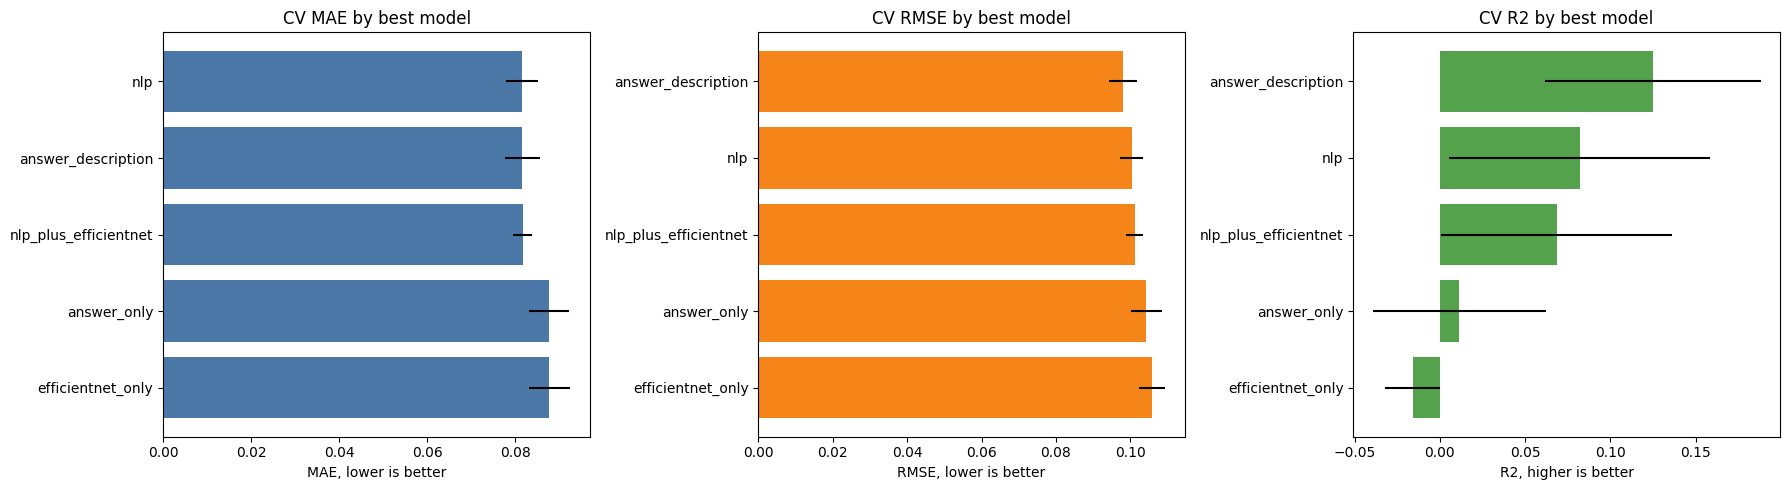

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = best_by_approach.sort_values("mae_mean")
axes[0].barh(plot_data["approach"], plot_data["mae_mean"], xerr=plot_data["mae_std"], color="#4c78a8")
axes[0].set_title("CV MAE by best model")
axes[0].set_xlabel("MAE, lower is better")
axes[0].invert_yaxis()

plot_data = best_by_approach.sort_values("rmse_mean")
axes[1].barh(plot_data["approach"], plot_data["rmse_mean"], xerr=plot_data["rmse_std"], color="#f58518")
axes[1].set_title("CV RMSE by best model")
axes[1].set_xlabel("RMSE, lower is better")
axes[1].invert_yaxis()

plot_data = best_by_approach.sort_values("r2_mean", ascending=False)
axes[2].barh(plot_data["approach"], plot_data["r2_mean"], xerr=plot_data["r2_std"], color="#54a24b")
axes[2].set_title("CV R2 by best model")
axes[2].set_xlabel("R2, higher is better")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## Holdout-графики для лучших моделей каждого подхода

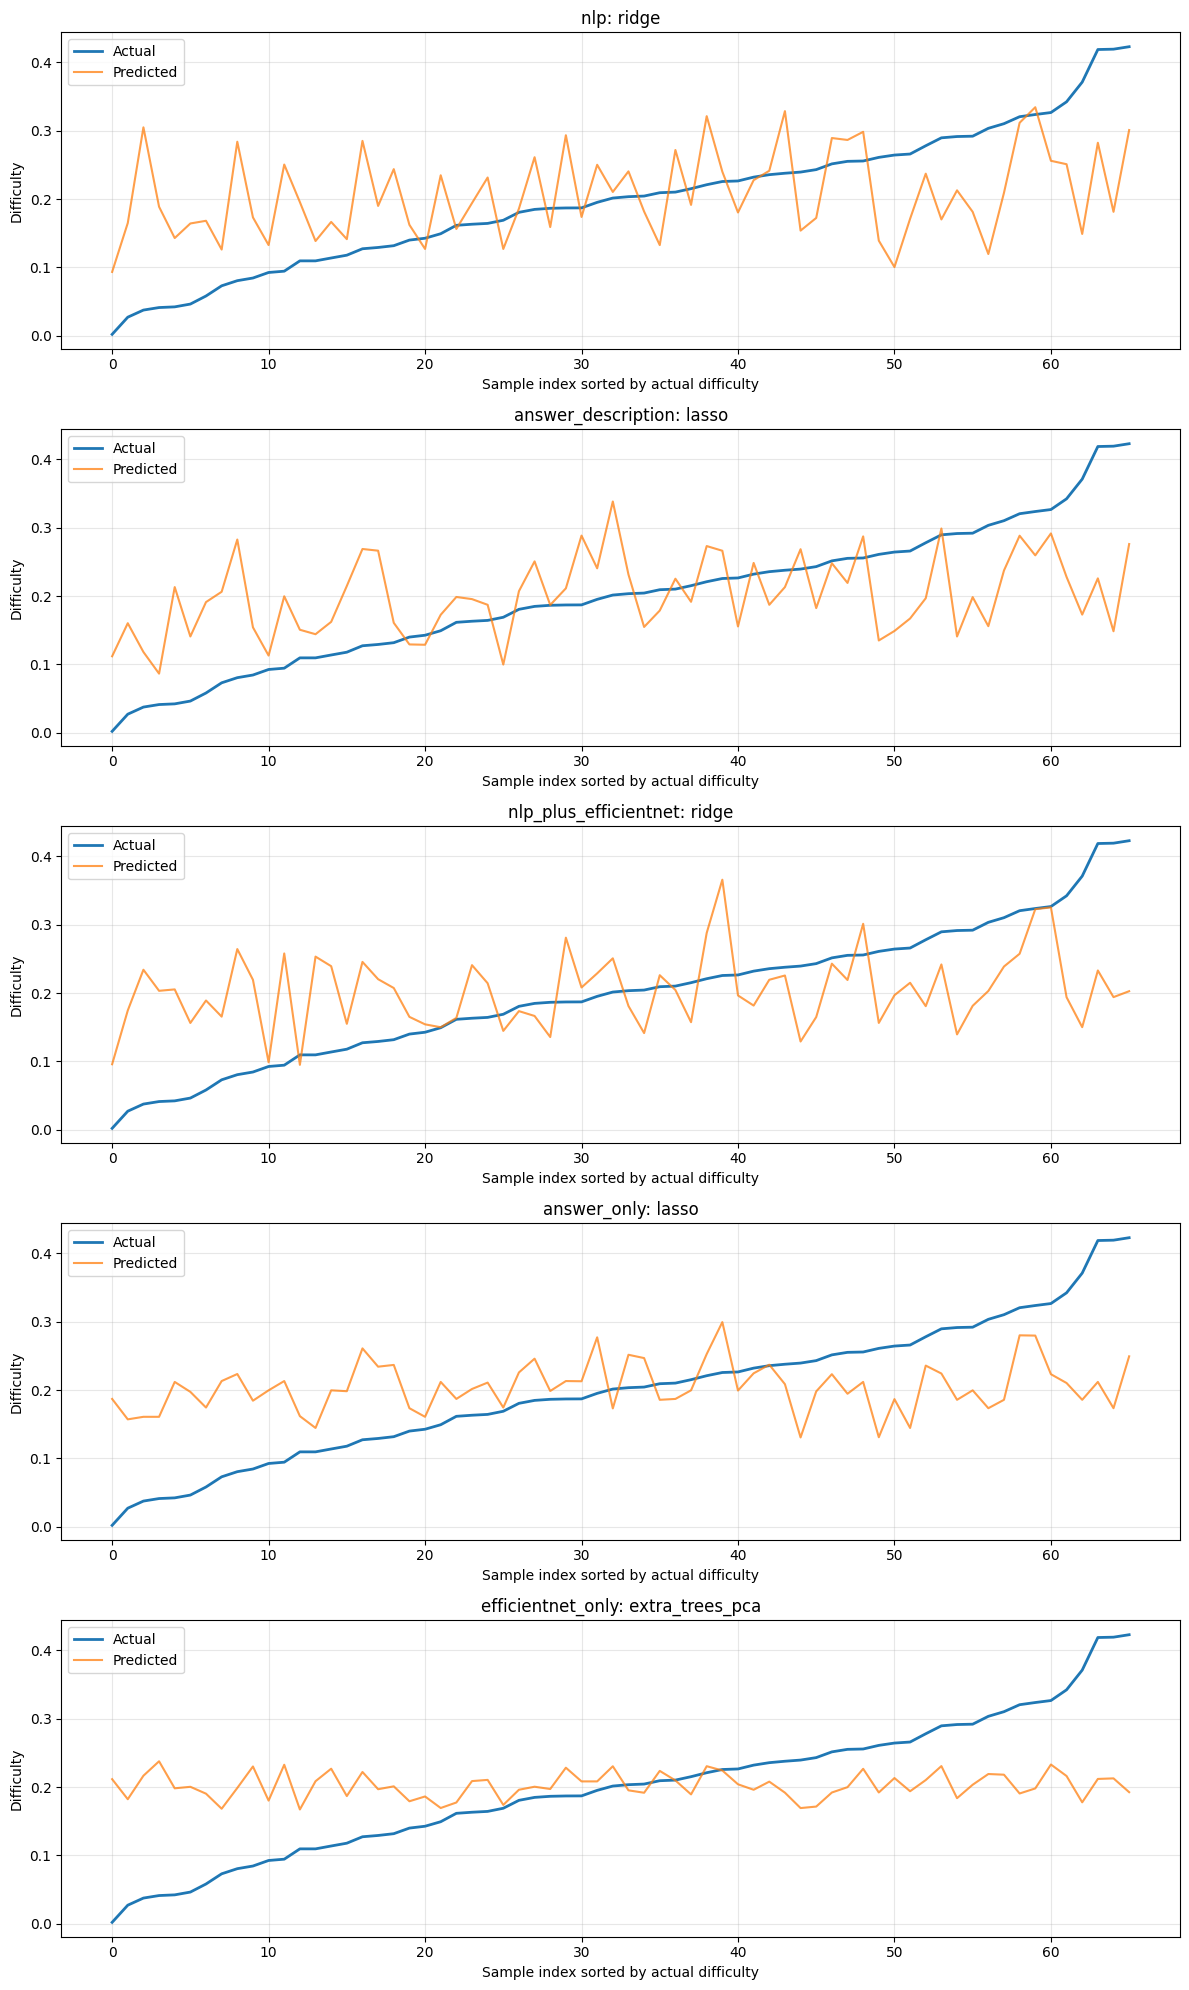

,approach,model,mae,rmse,r2
0,answer_description,lasso,0.074960,0.094393,0.083680
1,efficientnet_only,extra_trees_pca,0.078686,0.099122,-0.010441
2,nlp,ridge,0.079754,0.099646,-0.021154
3,nlp_plus_efficientnet,ridge,0.080064,0.101269,-0.054690
4,answer_only,lasso,0.080938,0.097890,0.014526


In [10]:
holdout_rows = []
fig, axes = plt.subplots(len(best_by_approach), 1, figsize=(12, 4 * len(best_by_approach)))
if len(best_by_approach) == 1:
    axes = [axes]

for ax, row in zip(axes, best_by_approach.itertuples(index=False)):
    approach_name = row.approach
    if approach_name.endswith("_plus_efficientnet"):
        X_current = X_combined
        models_current = combined_models
    else:
        X_current = approaches[approach_name]["X"]
        models_current = approaches[approach_name]["models"]

    X_train, X_test, y_train, y_test = train_test_split(X_current, y, test_size=0.2, random_state=RANDOM_STATE)
    model = clone(models_current[row.model])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    holdout_rows.append(
        {
            "approach": approach_name,
            "model": row.model,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": rmse_score(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
        }
    )

    plot_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).sort_values("Actual").reset_index(drop=True)
    ax.plot(plot_df["Actual"].values, label="Actual", linewidth=2)
    ax.plot(plot_df["Predicted"].values, label="Predicted", alpha=0.75)
    ax.set_title(f"{approach_name}: {row.model}")
    ax.set_xlabel("Sample index sorted by actual difficulty")
    ax.set_ylabel("Difficulty")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

holdout_metrics = pd.DataFrame(holdout_rows).sort_values("mae").reset_index(drop=True)
holdout_metrics